# A boat as a Lagrangian mechanics problem

A boat bobbing at anchor is two small-oscillation problems in disguise:
**heave** (vertical bobbing) and **roll** (rocking side to side). Neither
needs a free-body diagram -- write $L = T - V$ once for each coordinate,
grind the Euler-Lagrange equation, and the restoring physics (buoyancy,
metacentric stability) falls out as simple harmonic motion.

Every claim below is checked two ways: once symbolically (SymPy, via
`dgs.lagrangian.euler_lagrange` -- the same helper the pendulum/orbit
notebook uses), once via the closed-form naval-architecture formula, and
the notebook asserts they agree to numerical precision rather than just
asserting the formula is right.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt

from dgs import boat_lagrangian as boat
from dgs.lagrangian import euler_lagrange
print("loaded dgs.boat_lagrangian, dgs.lagrangian")

loaded dgs.boat_lagrangian, dgs.lagrangian


## Part 1 -- Heave: vertical bobbing

Displace the hull up by $x$ from its equilibrium waterline and it loses
submerged volume $A_{wp}\,x$ ($A_{wp}$ = waterplane area, the hull's
cross-section at the waterline). By Archimedes' principle that's a
buoyancy *deficit* $\rho g A_{wp} x$ pulling the hull back down -- a
restoring force linear in $x$, exactly like a spring with
$k_{eff} = \rho g A_{wp}$.

The kinetic energy carries **added mass** $m_{added}$: accelerating the
hull vertically also accelerates some of the water around it, so the
effective inertia is $(m + m_{added})$, not just the dry hull mass. This
is a real correction used in naval architecture, not a modeling nicety --
typically 0.1-1.0x the displaced mass for heave.

$$L = \tfrac{1}{2}(m + m_{added})\dot{x}^2 - \tfrac{1}{2}\rho g A_{wp} x^2$$

In [2]:
t = sp.Symbol('t')
m, m_added, rho, g, A_wp = sp.symbols('m m_added rho g A_wp', positive=True)
x = sp.Function('x')(t)

L_heave = boat.heave_lagrangian(x, t, m, m_added, rho, g, A_wp)
eom_heave = euler_lagrange(L_heave, x, t)
print('L =', L_heave)
print('Euler-Lagrange EOM:', eom_heave, '= 0')

L = -A_wp*g*rho*x(t)**2/2 + (m/2 + m_added/2)*Derivative(x(t), t)**2
Euler-Lagrange EOM: A_wp*g*rho*x(t) + (m + m_added)*Derivative(x(t), (t, 2)) = 0


The equation of motion is $(m+m_{added})\ddot{x} + \rho g A_{wp} x = 0$ --
simple harmonic motion with $\omega_{heave}^2 = \dfrac{\rho g A_{wp}}{m + m_{added}}$.
`dgs.boat_lagrangian.verify_heave_eom` extracts that coefficient directly
from the symbolic EOM above and checks it against
`heave_natural_frequency`'s closed form.

In [3]:
heave_check = boat.verify_heave_eom(m_val=5000.0, m_added_val=800.0,
                                     rho_val=boat.RHO_SEAWATER, g_val=boat.G_STANDARD,
                                     A_wp_val=12.0)
print(f"omega (from symbolic EOM):  {heave_check['omega_symbolic_rad_s']:.5f} rad/s")
print(f"omega (closed form):        {heave_check['omega_closed_form_rad_s']:.5f} rad/s")
print(f"agree exactly: {heave_check['matches']}")
T_heave = 2*np.pi/heave_check['omega_closed_form_rad_s']
print(f"heave period: {T_heave:.2f} s")

omega (from symbolic EOM):  4.56036 rad/s
omega (closed form):        4.56036 rad/s
agree exactly: True
heave period: 1.38 s


### Sanity checks: does the formula respond the right *direction* to physics?

Two things should be true if this formula means what it claims to mean:
- More added mass (more inertia) should **lower** the natural frequency.
- Denser water (seawater vs. freshwater) should give a **stiffer**
  restoring force and **raise** the natural frequency, for the same hull.

In [4]:
w_no_added = boat.heave_natural_frequency(5000.0, 0.0, boat.RHO_SEAWATER, boat.G_STANDARD, 12.0)
w_with_added = boat.heave_natural_frequency(5000.0, 800.0, boat.RHO_SEAWATER, boat.G_STANDARD, 12.0)
print(f"omega, no added mass:   {w_no_added:.5f} rad/s")
print(f"omega, with added mass: {w_with_added:.5f} rad/s  (lower, as expected: {w_with_added < w_no_added})")

w_fresh = boat.heave_natural_frequency(5000.0, 800.0, boat.RHO_FRESHWATER, boat.G_STANDARD, 12.0)
w_sea = boat.heave_natural_frequency(5000.0, 800.0, boat.RHO_SEAWATER, boat.G_STANDARD, 12.0)
print(f"omega, freshwater: {w_fresh:.5f} rad/s")
print(f"omega, seawater:   {w_sea:.5f} rad/s  (higher, as expected: {w_sea > w_fresh})")

omega, no added mass:   4.91166 rad/s
omega, with added mass: 4.56036 rad/s  (lower, as expected: True)
omega, freshwater: 4.50440 rad/s
omega, seawater:   4.56036 rad/s  (higher, as expected: True)


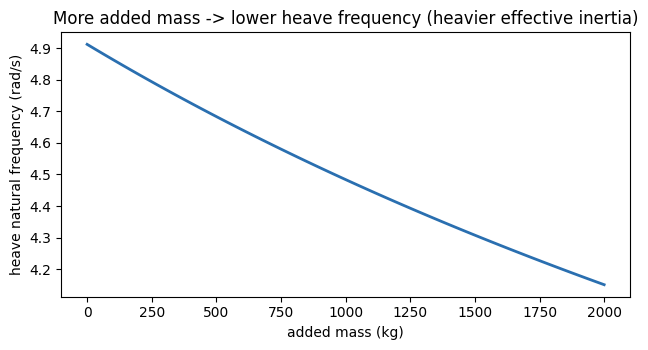

In [5]:
masses_added = np.linspace(0, 2000, 60)
omegas = [boat.heave_natural_frequency(5000.0, ma, boat.RHO_SEAWATER, boat.G_STANDARD, 12.0) for ma in masses_added]

fig, ax = plt.subplots(figsize=(6.5, 3.6))
ax.plot(masses_added, omegas, color='#2a6fb0', lw=2)
ax.set_xlabel('added mass (kg)')
ax.set_ylabel('heave natural frequency (rad/s)')
ax.set_title('More added mass -> lower heave frequency (heavier effective inertia)')
fig.tight_layout()
plt.show()

## Part 2 -- Roll: rocking about the fore-aft axis

The restoring moment for a small heel angle $\theta$ is
$\rho g \nabla \, GM \, \theta$, where $\nabla$ is the displaced volume and
$GM$ is the **metacentric height** -- the classic naval-architecture
stability margin. $GM > 0$ means the righting moment pushes the boat back
upright; $GM \le 0$ means it doesn't (real instability, or capsize).

$$L = \tfrac{1}{2} I_{roll}\dot\theta^2 - \tfrac{1}{2}\rho g \nabla\, GM\, \theta^2$$

In [6]:
I_roll, nabla, GM = sp.symbols('I_roll nabla GM', positive=True)
theta = sp.Function('theta')(t)

L_roll = boat.roll_lagrangian(theta, t, I_roll, rho, g, nabla, GM)
eom_roll = euler_lagrange(L_roll, theta, t)
print('L =', L_roll)
print('Euler-Lagrange EOM:', eom_roll, '= 0')

L = -GM*g*nabla*rho*theta(t)**2/2 + I_roll*Derivative(theta(t), t)**2/2
Euler-Lagrange EOM: GM*g*nabla*rho*theta(t) + I_roll*Derivative(theta(t), (t, 2)) = 0


### The mass-cancellation shortcut

Naval architecture texts quote the roll period as
$T_{roll} = 2\pi k/\sqrt{g\,GM}$ ($k$ = roll radius of gyration) with the
vessel's mass nowhere in sight. That's only true because
$I_{roll} = m k^2$ and, by Archimedes, $m = \rho \nabla$ -- the mass
built into $I_{roll}$ exactly cancels the mass built into the restoring
term. `verify_roll_period_shortcut` builds $I_{roll}$ from an explicit
mass instead of assuming the cancellation, then checks the two routes
still agree.

In [7]:
roll_check = boat.verify_roll_period_shortcut(k_roll_val=3.0, GM_val=1.2,
                                                g_val=boat.G_STANDARD,
                                                rho_val=boat.RHO_SEAWATER, nabla_val=400.0)
print(f"period, full formula (I_roll = m k^2 built explicitly): {roll_check['period_from_omega_s']:.3f} s")
print(f"period, 2*pi*k/sqrt(g*GM) shortcut:                     {roll_check['period_from_shortcut_s']:.3f} s")
print(f"agree exactly: {roll_check['matches']}")

period, full formula (I_roll = m k^2 built explicitly): 5.495 s
period, 2*pi*k/sqrt(g*GM) shortcut:                     5.495 s
agree exactly: True


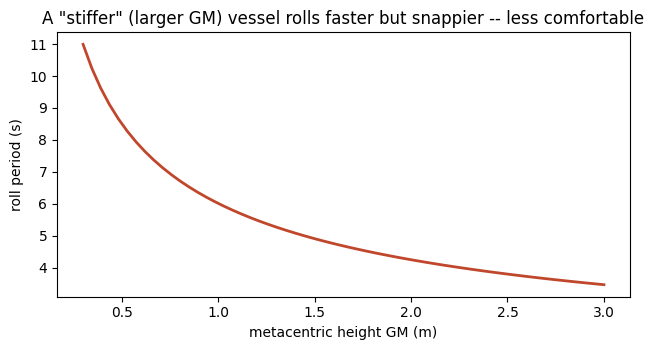

In [8]:
GM_values = np.linspace(0.3, 3.0, 60)
periods = [boat.roll_period_from_radius_of_gyration(k_roll=3.0, GM=g) for g in GM_values]

fig, ax = plt.subplots(figsize=(6.5, 3.6))
ax.plot(GM_values, periods, color='#c0472c', lw=2)
ax.set_xlabel('metacentric height GM (m)')
ax.set_ylabel('roll period (s)')
ax.set_title('A "stiffer" (larger GM) vessel rolls faster but snappier -- less comfortable')
fig.tight_layout()
plt.show()

## Summary

| Mode | Coordinate | Restoring term | Inertia | omega |
|---|---|---|---|---|
| Heave | $x$ (vertical) | $\rho g A_{wp}$ (buoyancy) | $m + m_{added}$ | $\sqrt{\rho g A_{wp}/(m+m_{added})}$ |
| Roll | $\theta$ (heel angle) | $\rho g \nabla\, GM$ (righting moment) | $I_{roll}$ | $\sqrt{\rho g \nabla\, GM/I_{roll}}$ |

Same recipe as `dgs.lagrangian`'s pendulum and orbit: write $L=T-V$ for the
right coordinate, let Euler-Lagrange do the algebra, and check the answer
against an independent formula before trusting it. A larger $GM$ makes a
vessel *more* stable (less likely to capsize) but also *less* comfortable
to be aboard -- it snaps back to upright faster, which is exactly the
kind of counter-intuitive-until-you-derive-it result this recipe is
supposed to surface.